In [1]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

## Saturn Test Particle

### Getting f_d terms

In [10]:
#1st order verpi_sat

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.87

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n1vs = pham.state.particles[2].n

fd_1vs = df_coefficient_Ctilde(k1=2, k2=-1, k3=0, k4=-1, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True)

fd_1vs = evaluate_df_coefficient_dict(fd_1vs, alpha)

In [11]:
#first order varpi_jup

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.87

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n1vj = pham.state.particles[2].n

fd_1vj = df_coefficient_Ctilde(k1=2, k2=-1, k3=-1, k4=0, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True)

fd_1vj = evaluate_df_coefficient_dict(fd_1vj, alpha)

In [18]:
#second Order mixed

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")


sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n2 = pham.state.particles[2].n

fd_2 = df_coefficient_Ctilde(k1=4, k2=-2, k3=-1, k4=-1, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True)

fd_2 = evaluate_df_coefficient_dict(fd_2, alpha)

In [19]:
#third order mixed 2* varpi_sat

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")


sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n3vs = pham.state.particles[2].n

fd_3vs = df_coefficient_Ctilde(k1=6, k2=-3, k3=-1, k4=-2, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_3vs = evaluate_df_coefficient_dict(fd_3vs, alpha)

In [14]:
#third order mixed 2 * varpi_jup

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n3vj = pham.state.particles[2].n

fd_3vj = df_coefficient_Ctilde(k1=6, k2=-3, k3=-2, k4=-1, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_3vj = evaluate_df_coefficient_dict(fd_3vj, alpha)

In [27]:
# fourth order mixed

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3)

n4 = pham.state.particles[2].n

fd_4 = df_coefficient_Ctilde(k1=8, k2=-4, k3=-2, k4=-2, k5=0, k6=0, nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = False)

fd_4 = evaluate_df_coefficient_dict(fd_4, alpha)

### evaluating stuff

In [28]:
def c_r(m, n, alpha):
    return m * n * alpha

c_r_1vs = c_r(m_jup,n1vs,alpha)

c_r_1vj = c_r(m_jup, n1vj, alpha)

c_r_2 = c_r(m_jup, n2, alpha)

c_r_3vs = c_r(m_jup, n3vs, alpha)

c_r_3vj = c_r(m_jup, n3vj, alpha)

c_r_4 = c_r(m_jup,n4,alpha)

def a_max_21(e, c_r_val, fd, n, a, j2):
    x = (np.abs(c_r_val) / n) * np.abs(fd)
    return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)

def a_max(e, c_r_val, fd, n, a, order):
    return a * np.sqrt((16/3) * (c_r_val/n) * np.abs(fd) * e**order)

## graphing stuff

/tmp/ipykernel_2629/524861779.py:18: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_2629/524861779.py:18: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


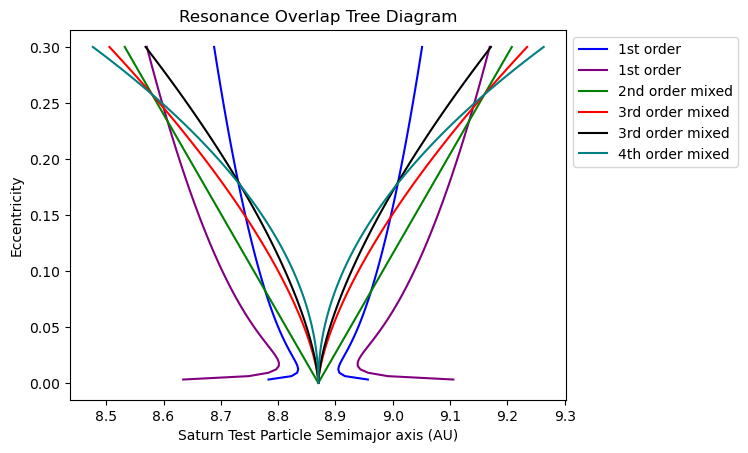

In [29]:
ecc_vals = np.linspace(0,0.3,100)

plt.plot(8.87 + a_max_21(ecc_vals, c_r_1vs,fd_1vs, n1vs, 8.87,2),ecc_vals, color = 'blue', label = f'1st order')
plt.plot(8.87 - a_max_21(ecc_vals, c_r_1vs,fd_1vs, n1vs, 8.9,2),ecc_vals, color = 'blue')

plt.plot(8.87 + a_max_21(ecc_vals, c_r_1vj,fd_1vj, n1vj, 8.87,2),ecc_vals, color = 'purple', label = f'1st order')
plt.plot(8.87 - a_max_21(ecc_vals, c_r_1vj,fd_1vj, n1vj, 8.87,2),ecc_vals, color = 'purple')

plt.plot(8.87 + a_max(ecc_vals, c_r_2,fd_2, n2, 8.87, 2),ecc_vals, color = 'green', label = f'2nd order mixed')
plt.plot(8.87 - a_max(ecc_vals, c_r_2,fd_2, n2,8.87, 2),ecc_vals, color = 'green')

plt.plot(8.87 + a_max(ecc_vals, c_r_3vs,fd_3vs, n3vs,8.87, 3), ecc_vals, color = 'red', label = f'3rd order mixed')
plt.plot(8.87 - a_max(ecc_vals, c_r_3vs,fd_3vs, n3vs,8.87, 3), ecc_vals, color = 'red')

plt.plot(8.87 + a_max(ecc_vals, c_r_3vj,fd_3vj, n3vj, 8.87, 3), ecc_vals, color = 'black', label = f'3rd order mixed')
plt.plot(8.87 - a_max(ecc_vals, c_r_3vj,fd_3vj, n3vj, 8.87, 3), ecc_vals, color = 'black')


plt.plot(8.87 + a_max(ecc_vals, c_r_4,fd_4, n3vj, 8.87, 4), ecc_vals, color = 'teal', label = f'4th order mixed')
plt.plot(8.87 - a_max(ecc_vals, c_r_4,fd_4, n4, 8.87, 4), ecc_vals, color = 'teal')

plt.ylabel('Eccentricity')
plt.xlabel('Saturn Test Particle Semimajor axis (AU)')
plt.title('Resonance Overlap Tree Diagram')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=1.0)
plt.show()

AttributeError: 'PoincareParticle' object has no attribute 'L'

<Figure size 1000x600 with 0 Axes>